In [1]:
"""
Plan is to deconvolute the macrophage behaviors in the responders pre and post biopsy and show that these matrices can be harmonized
and then do pathway analysis to demonstrate their change in behavior. Pseudobulk them? 
"""



'\nPlan is to deconvolute the macrophage behaviors in the responders pre and post biopsy and show that these matrices can be harmonized\nand then do pathway analysis to demonstrate their change in behavior. Pseudobulk them? \n'

In [2]:
# Core Biopsies
biopsy_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS22-14789/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-4809-A/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/NRS23_22932/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/TMS23-01580/outs']

# Surgical Specimens Only For Now
surg_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS-7945/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-8883/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-13045_rep/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS24-3385-D/outs']

In [ ]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [ ]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


In [4]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


## Core Biopsies

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 2256
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "10.201.0.113"


Refining Cell Proportions: 100%|██████████| 2256/2256 [05:44<00:00,  6.55it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATCTAATGACCGG-1', 'AACATCTTAAGGCTCA-1', 'AACCAAGGTATCAGGC-1', 'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1']
AnnData spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

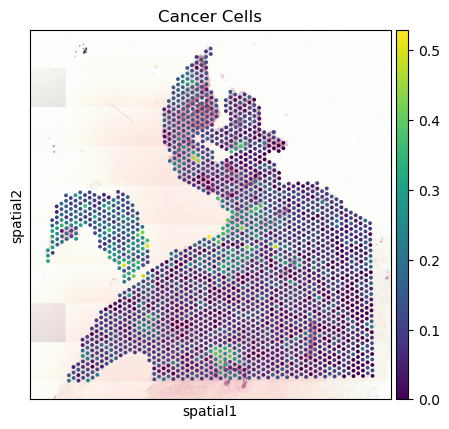

Deconvoluting Remaining Spots: 100%|██████████| 2256/2256 [11:25<00:00,  3.29it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACAGGATTCATAGTT-1' 'AACAGGTTATTGCACC-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Macrophages_genes_pass1 (Shape: (2256, 4860))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: B_Cells_genes_pass1 (Shape: (2256, 4860))
Added layer: Fibroblasts_genes_pass1 (Shape: (2256, 4860))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (2256, 4860))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 423
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 423/423 [00:57<00:00,  7.37it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCGCTTAGTCAG-1', 'AAGAATTCTGGCTGCA-1', 'AAGCAGCGGACACGTG-1', 'AAGGCCGACCTACCTG-1', 'AAGGCCGATTCTGAGC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'

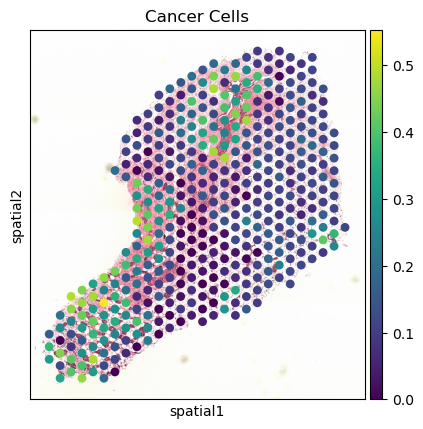

Deconvoluting Remaining Spots: 100%|██████████| 423/423 [01:27<00:00,  4.81it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1',
       'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACTATGCTGCATTCG-1' 'AACTCAACCTTGACCA-1'
 'AACTGCCTCGATAGGT-1' 'AACTTCAGATACTACC-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Macrophages_genes_pass1 (Shape: (423, 12251))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: B_Cells_genes_pass1 (Shape: (423, 12251))
Added layer: Fibroblasts_genes_pass1 (Shape: (423, 12251))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (423, 12251))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACTATGCTGCA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1783
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 1783/1783 [02:52<00:00, 10.31it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACATAGTCTATCTAC-1', 'AACATGACGCAGCGTG-1', 'AACCACTGCCATAGCC-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'

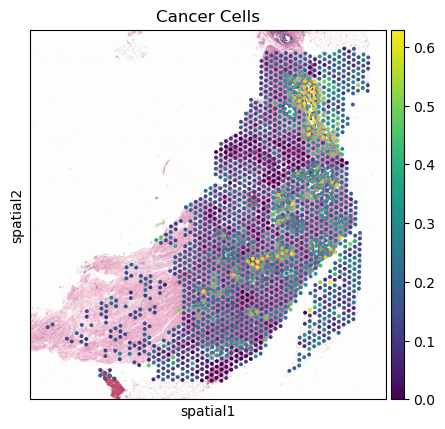

Deconvoluting Remaining Spots: 100%|██████████| 1783/1783 [05:45<00:00,  5.16it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1',
       'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACAGGATTCATAGTT-1' 'AACAGGTTCACCGAAG-1'
 'AACAGTCAGGCTCCGC-1' 'AACAGTCCACGCGGTG-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Macrophages_genes_pass1 (Shape: (1783, 2622))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: B_Cells_genes_pass1 (Shape: (1783, 2622))
Added layer: Fibroblasts_genes_pass1 (Shape: (1783, 2622))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (1783, 2622))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACAGGATTCAT

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 320
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 320/320 [00:40<00:00,  7.83it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACATCCTACTC-1', 'AATTGCATTGAAGAAT-1', 'AATTGGTTATGATACA-1', 'ACAGGAACTACAGAAC-1']
AnnData spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'

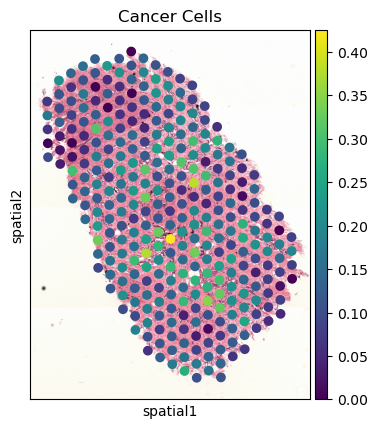

Deconvoluting Remaining Spots: 100%|██████████| 320/320 [01:00<00:00,  5.30it/s]


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AACTGCCTCGATAGGT-1',
       'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1'],
      dtype='object')
Parquet spot names format: ['AACACTTGGCAAGGAA-1' 'AACCGCCAGACTACTT-1' 'AACTGCCTCGATAGGT-1'
 'AAGGCCGACCTACCTG-1' 'AAGTACTGGATGCGCA-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Macrophages_genes_pass1 (Shape: (320, 8632))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: B_Cells_genes_pass1 (Shape: (320, 8632))
Added layer: Fibroblasts_genes_pass1 (Shape: (320, 8632))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (320, 8632))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1'

In [5]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in biopsy_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-1]

        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color = "Cancer Cells")

    
    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)






## Surgical Specimens

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4992
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4992/4992 [08:49<00:00,  9.42it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


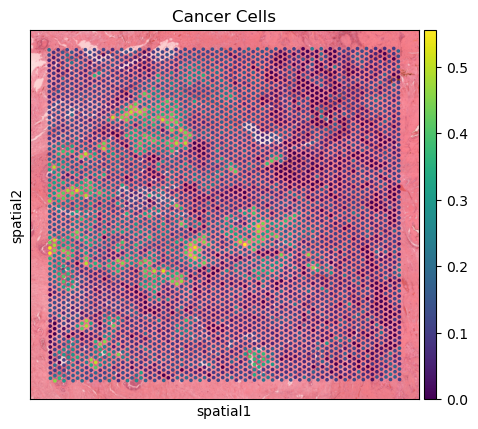

Deconvoluting Remaining Spots: 100%|██████████| 4992/4992 [55:44<00:00,  1.49it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Macrophages_genes_pass1 (Shape: (4992, 6544))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: B_Cells_genes_pass1 (Shape: (4992, 6544))
Added layer: Fibroblasts_genes_pass1 (Shape: (4992, 6544))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4992, 6544))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4847
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4847/4847 [11:32<00:00,  7.00it/s]
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'

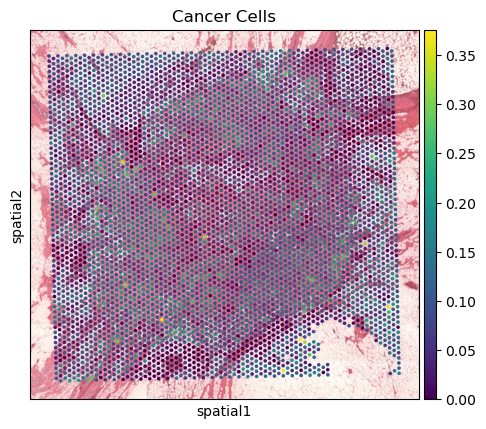

Deconvoluting Remaining Spots: 100%|██████████| 4847/4847 [1:10:11<00:00,  1.15it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Macrophages_genes_pass1 (Shape: (4847, 9527))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: B_Cells_genes_pass1 (Shape: (4847, 9527))
Added layer: Fibroblasts_genes_pass1 (Shape: (4847, 9527))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4847, 9527))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4450
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions: 100%|██████████| 4450/4450 [11:13<00:00,  6.61it/s]



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical



Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCGTGTCGCGG-1', 'AACATACTCATATGCG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
✅ Returning the internal AnnData object.


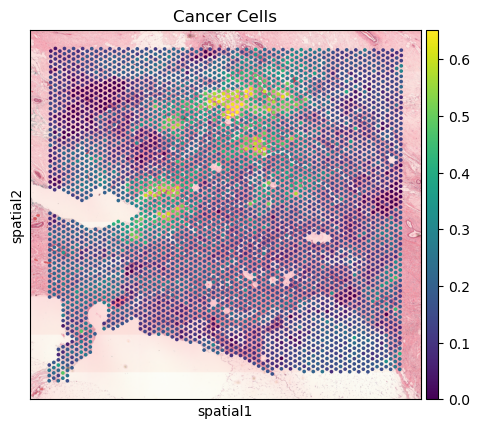

Deconvoluting Remaining Spots: 100%|██████████| 4450/4450 [22:12<00:00,  3.34it/s]  


Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1',
       'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1'],
      dtype='object')
Parquet spot names format: ['AACACCTACTATCGAA-1' 'AACACGTGCATCGCAC-1' 'AACACTTGGCAAGGAA-1'
 'AACAGGAAGAGCATAG-1' 'AACAGGATTCATAGTT-1']
Added layer: Cancer_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: CD4_T_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Macrophages_genes_pass1 (Shape: (4450, 2564))
Added layer: Endothelial_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: B_Cells_genes_pass1 (Shape: (4450, 2564))
Added layer: Fibroblasts_genes_pass1 (Shape: (4450, 2564))
Added layer: CD8_T_Cells_genes_pass1 (Shape: (4450, 2564))
Parquet file for pass 1 loaded successfully.
Spot and CellType successfully split.

Spot name formats:
AnnData spot names format: Index(['AACACCTACTATCGAA-1', 'AACACGTGCATC

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4824
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic


Refining Cell Proportions:  39%|███▉      | 1878/4824 [04:03<06:21,  7.72it/s]


In [ ]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


for path in surg_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-1]

        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    global_cell_type_proportions_df, finetuned_cell_type_proportions_df = model.run_cell_proportion_model(radius=400)

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    prop_adata = model.get_adata()

    sc.pl.spatial(prop_adata, color = "Cancer Cells")

    
    pass1_results = model.run_cell_expression_pass1(
                radius=400, 
                max_workers=None, 
                checkpoint_interval=100, 
                output_dir="checkpoints", 
                rerun=True
            )

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)






# Analyzing Macrophage Behavior (Load from saved files so samples don't have to be re-run)

In [2]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [3]:
import scanpy as sc
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing


In [4]:
# Core Biopsies
biopsy_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS22-14789/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-4809-A/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/NRS23_22932/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/TMS23-01580/outs']

# Surgical Specimens Only For Now
surg_responding_paths = ['/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS-7945/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-8883/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS23-13045_rep/outs',
                        '/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/PVS24-3385-D/outs']

In [5]:
cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


In [6]:
biopsy_adatas = {}

for path in biopsy_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-2]


        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='../output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")


    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    biopsy_adatas[sample_name] = prop_gex_adata



/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 4860 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 1898 Filtered spots: 2256 to 1898
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACAT

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 12251 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 420 Filtered spots: 423 to 420
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACTATGCTGCATTCG-1', 'AACTCAACCTTGACCA-1', 'AACTGCCTCGATAGGT-1', 'AACTTCAGATACTACC-1', 'AACTTCG

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2622 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 935 Filtered spots: 2142 to 935
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACAGGATTCATAGTT-1', 'AACAGGTTCACCGAAG-1', 'AACCAGAATCAGACGT-1', 'AACCGCCAGACTACTT-1', 'AACCTAA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 8632 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 300 Filtered spots: 328 to 300
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic
✅ Returning the internal AnnData object.

Before sorting:
CSV spots 1-10: ['AACACTTGGCAAGGAA-1', 'AACCGCCAGACTACTT-1', 'AAGGCCGACCTACCTG-1', 'AAGTACTGGATGCGCA-1', 'AATAACATGTTACGTC-1', 'AATGGACA

In [7]:
surg_adatas = {}

for path in surg_responding_paths:
    adata = sc.read_visium(path, count_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

    sample_name = path.split('/')[-2]


        # Initialize the model
    model = CitegeistModel(sample_name=sample_name, adata=adata, output_folder='../output')

    # Load cell profile dictionary
    model.load_cell_profile_dict(cell_profiles)

    # Preprocess and run models
    # Split into gene expression and antibody capture datasets
    model.split_adata()

    model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

    model.copy_gex_to_protein_adata()

    # Preprocess datasets
    model.preprocess_gex()
    model.preprocess_antibody()
    print(model)

    # Register Gurobi license
    model.register_gurobi("/ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic")

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='global')

    # Run gene expression model (if needed)
    # model.run_gex_model()
    prop_adata = model.get_adata()

    # Plot cell proportions (Append cell proportions) 
    model.append_proportions_to_adata(key='finetuned')

    # Plot cell proportions (Append cell proportions) 
    model.append_gex_to_adata(pass_number=1)


    prop_gex_adata = model.get_adata()

    print(prop_gex_adata)

    surg_adatas[sample_name] = prop_gex_adata



/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 6544 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4590 Filtered spots: 4992 to 4590
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9527 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4449 Filtered spots: 4858 to 4449
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 2564 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4267 Filtered spots: 4450 to 4267
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AA

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 9509 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4773 Filtered spots: 4824 to 4773
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.
CitegeistModel Summary:
- Output Folder: ../output
- Main AnnData Loaded: Yes
- Gene Expression AnnData Loaded: Yes
- Antibody Capture AnnData Loaded: Yes
- Cell Profile Dictionary Loaded: Yes
- Gene Expression Preprocessed: Yes
- Antibody Capture Preprocessed: Yes
✅ Gurobi license file has been successfully configured.
 - GRB_LICENSE_FILE: /ihome/crc/install/gurobi/gurobi1102/linux64/lic/gurobi.lic

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACGTGCATCGCAC-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AA

In [8]:
all_adatas = []

for sample_name, adata in biopsy_adatas.items():
    print(adata)
    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs['Macrophages'] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers['Macrophages_genes_pass1']
    macrophage_adata.obs['sample_name'] = sample_name
    macrophage_adata.obs['condition'] = 'Biopsy'
    all_adatas.append(macrophage_adata)
    

AnnData object with n_obs × n_vars = 1898 × 4860
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Macrophages_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1'
AnnData object with n_obs × n_vars = 420 × 12251
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/scratch/slurm-4893982/ipykernel_41385/2302642185.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential

AnnData object with n_obs × n_vars = 300 × 8632
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Macrophages_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1'


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/scratch/slurm-4893982/ipykernel_41385/2302642185.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


In [9]:
for sample_name, adata in surg_adatas.items():
    print(adata)
    # Filter down to the spots where Macrophage Proportion is greater than 0.2
    macrophage_adata = adata[adata.obs['Macrophages'] > 0.2]
    # Then set the X matrix to the Macrophage layers
    macrophage_adata.X = macrophage_adata.layers['Macrophages_genes_pass1']
    macrophage_adata.obs['sample_name'] = sample_name
    macrophage_adata.obs['condition'] = 'Surgery'
    all_adatas.append(macrophage_adata)
    

AnnData object with n_obs × n_vars = 4590 × 6544
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Macrophages_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1'


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/scratch/slurm-4893982/ipykernel_41385/2269674914.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


AnnData object with n_obs × n_vars = 4449 × 9527
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Macrophages_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1'


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/scratch/slurm-4893982/ipykernel_41385/2269674914.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name


AnnData object with n_obs × n_vars = 4267 × 2564
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Macrophages_genes_pass1', 'Endothelial_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'B_Cells_genes_pass1'
AnnData object with n_obs × n_vars = 4773 × 9509
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/scratch/slurm-4893982/ipykernel_41385/2269674914.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  macrophage_adata.obs['sample_name'] = sample_name
/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:618: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential

In [10]:
import anndata as ad
import numpy as np

adata_spots = 0

for adata in all_adatas:
    adata_spots += adata.shape[0]
    
print(adata_spots)

# Create concatenated AnnData object
combined_adata = ad.concat(
    all_adatas,
    label="sample_name",  # This will store the source in .obs['celltype']
    join="outer"  # Use outer join to keep all genes
)

assert adata_spots == combined_adata.shape[0]
combined_adata.obs_names_make_unique()
print(combined_adata.obs_names)
print(combined_adata.obs['condition'].unique())
print(combined_adata.obs['sample_name'])

combined_adata.X = np.nan_to_num(combined_adata.X, nan=0)


3645


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Index(['AACAGGATTCATAGTT-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1',
       'AACCAATCTGGTTGGC-1', 'AACCACTAACATGATT-1', 'AACCTACCTACCGGTT-1',
       'AACCTACTGTAACTCA-1', 'AACGAAGCGTGGAAGT-1', 'AACGAGCTAATAACTA-1',
       'AACGCACTGGTGCTCG-1',
       ...
       'TGGCCAAGCTGGCACC-1', 'TGGCGAATTCTATGGT-1-1', 'TGGCGAGCCACTAGCG-1',
       'TGGTATTAGCTAGACC-1', 'TGGTCGAGATCTGTAA-1', 'TGGTGCATTGTAATCC-1-2',
       'TGTAATGCCTAACACC-1', 'TGTAGGTCTGAACGCA-1-2', 'TGTCAACTCATCAACG-1-1',
       'TGTTGGAACGAGGTCA-1'],
      dtype='object', length=3645)
['Biopsy' 'Surgery']
AACAGGATTCATAGTT-1      0
AACAGGTTATTGCACC-1      0
AACAGGTTCACCGAAG-1      0
AACCAATCTGGTTGGC-1      0
AACCACTAACATGATT-1      0
                       ..
TGGTGCATTGTAATCC-1-2    7
TGTAATGCCTAACACC-1      7
TGTAGGTCTGAACGCA-1-2    7
TGTCAACTCATCAACG-1-1    7
TGTTGGAACGAGGTCA-1      7
Name: sample_name, Length: 3645, dtype: category
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']


In [11]:
sc.pp.log1p(combined_adata)
sc.pp.pca(combined_adata)

In [12]:
import scanpy.external as sce
sce.pp.harmony_integrate(combined_adata, 'sample_name')

2025-01-29 15:47:22,452 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-29 15:47:28,108 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-29 15:47:28,130 - harmonypy - INFO - Iteration 1 of 10
2025-01-29 15:47:28,747 - harmonypy - INFO - Iteration 2 of 10
2025-01-29 15:47:29,819 - harmonypy - INFO - Iteration 3 of 10
2025-01-29 15:47:30,791 - harmonypy - INFO - Iteration 4 of 10
2025-01-29 15:47:31,355 - harmonypy - INFO - Iteration 5 of 10
2025-01-29 15:47:31,915 - harmonypy - INFO - Iteration 6 of 10
2025-01-29 15:47:32,477 - harmonypy - INFO - Iteration 7 of 10
2025-01-29 15:47:32,826 - harmonypy - INFO - Iteration 8 of 10
2025-01-29 15:47:33,390 - harmonypy - INFO - Iteration 9 of 10
2025-01-29 15:47:33,858 - harmonypy - INFO - Iteration 10 of 10
2025-01-29 15:47:34,374 - harmonypy - INFO - Stopped before convergence


/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/scratch/slurm-4893982/ipykernel_41385/3158926017.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(combined_adata, resolution=0.5)
... storing 'condition' as categorical


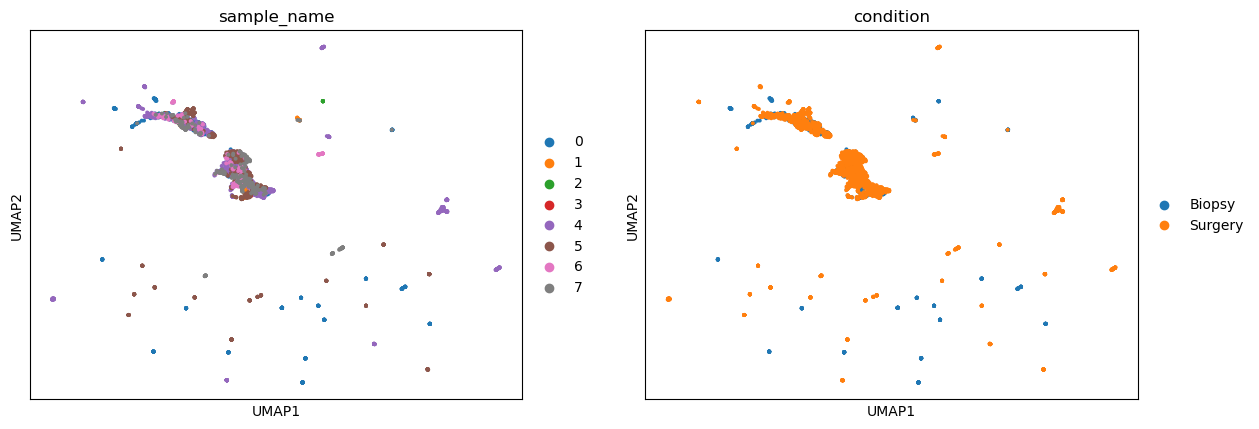

In [13]:
sc.pp.neighbors(combined_adata, n_neighbors=15, use_rep='X_pca_harmony')
sc.tl.leiden(combined_adata, resolution=0.5)
sc.tl.umap(combined_adata, min_dist=0.1)   
sc.pl.umap(combined_adata, color=['sample_name', 'condition'])

In [14]:
# And then do Pyseq2 

In [15]:
import pydeseq2
import pandas as pd

In [16]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

In [17]:
combined_adata.X = np.rint(np.expm1(combined_adata.X)).astype(int)  # Reversing because Deseq requires counts data

In [18]:
counts_array = np.rint(combined_adata.X)
counts_df = pd.DataFrame(
    data=counts_array,
    index=combined_adata.obs_names,
    columns=combined_adata.var_names
)
print(counts_df)

                       A2M  A4GALT  AAAS  AACS  AADAT  AAGAB  AAK1  AAMDC  \
AACAGGATTCATAGTT-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AACAGGTTATTGCACC-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AACAGGTTCACCGAAG-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AACCAATCTGGTTGGC-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
AACCACTAACATGATT-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
...                    ...     ...   ...   ...    ...    ...   ...    ...   
TGGTGCATTGTAATCC-1-2  31.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
TGTAATGCCTAACACC-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
TGTAGGTCTGAACGCA-1-2   0.0     0.0   6.0   0.0    0.0    0.0   0.0    0.0   
TGTCAACTCATCAACG-1-1   0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   
TGTTGGAACGAGGTCA-1     0.0     0.0   0.0   0.0    0.0    0.0   0.0    0.0   

                      AAMP  AAR2  ...  ZUP1  ZW10  ZWILCH  ZWINT  ZXDB  ZXD

In [ ]:
# Remove genes that have too many zeros
min_samples = 3  # Typically you want at least 3 samples with counts
min_counts = 10  # Minimum count threshold per gene

# Filter genes - keep only those that have at least min_counts in at least min_samples samples
genes_to_keep = counts_df.apply(lambda x: sum(x >= min_counts) >= min_samples, axis=1)
filtered_counts = counts_df.loc[genes_to_keep]

# Additional filter to ensure at least one non-zero value per gene
nonzero_genes = filtered_counts.apply(lambda x: sum(x > 0) > 0, axis=1)
filtered_counts = filtered_counts.loc[nonzero_genes]

print(f"Original gene count: {counts_df.shape[0]}")
print(f"Filtered gene count: {filtered_counts.shape[0]}")

In [19]:
sample_name = combined_adata.obs['sample_name']
condition = combined_adata.obs['condition']
print(sample_name.shape)
print(condition.shape)



# Ensure indices are identical before merging
if not sample_name.index.equals(condition.index):
    raise ValueError("Indices do not match between DataFrames!")
else:
    metadata_df = pd.concat([sample_name, condition], axis=1)

    print(metadata_df.shape)

(3645,)
(3645,)
(3645, 2)


In [20]:
print(counts_df.shape)
print(metadata_df.shape)
print(metadata_df.head())

(3645, 13266)
(3645, 2)
                   sample_name condition
AACAGGATTCATAGTT-1           0    Biopsy
AACAGGTTATTGCACC-1           0    Biopsy
AACAGGTTCACCGAAG-1           0    Biopsy
AACCAATCTGGTTGGC-1           0    Biopsy
AACCACTAACATGATT-1           0    Biopsy


In [21]:
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [22]:
# Sum across columns (genes) for each sample and keep samples with >= 10 counts
samples_to_keep = counts_df.index[counts_df.sum(axis=1) >= 10]
counts_df = counts_df.loc[samples_to_keep]


In [23]:
metadata_df = metadata_df.loc[counts_df.index]

In [24]:
print(counts_df.shape)
print(metadata_df.shape)

(2370, 11167)
(2370, 2)


In [27]:
# Calculate percentage of zeros for each sample (row)
zero_percentages = (counts_df == 0).sum(axis=1) / counts_df.shape[1] * 100

# Find samples with 95% or more zeros
high_zero_samples = zero_percentages[zero_percentages >= 95].index

# Remove those samples
filtered_counts = counts_df.drop(high_zero_samples)

print(f"Original sample count: {counts_df.shape[0]}")
print(f"Filtered sample count: {filtered_counts.shape[0]}")
print(f"Removed {len(high_zero_samples)} samples")

Original sample count: 2370
Filtered sample count: 751
Removed 1619 samples


In [28]:
filtered_metadata = metadata_df.loc[filtered_counts.index]

In [29]:
inference = DefaultInference(n_cpus=16)
dds = DeseqDataSet(
    counts=filtered_counts,
    metadata=filtered_metadata,
    design="~condition",
    refit_cooks=True,
    inference=inference,
)

In [ ]:
dds.deseq2()

Fitting size factors...
/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/singlecell/lib/python3.10/site-packages/pydeseq2/dds.py:532: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(


Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.53 seconds.

Fitting MAP dispersions...
... done in 2.42 seconds.



In [ ]:
print(dds.varm["LFC"])

In [ ]:
ds_B_vs_A = DeseqStats(dds, contrast=["condition", "Biopsy", "Surgery"], inference=inference)

In [ ]:
ds_B_vs_A.summary()

In [ ]:
ds_B_vs_A.lfc_shrink(coeff="condition[Biopsy.Surgery]")

In [ ]:
# And then do good old fashioned pathway analysis again

In [ ]:
import gseapy as gp
gp.get_library_name(organism='Human')